In [1]:
import torch
from chemxai.data import qm9_tabular
from chemxai.models import MLP

In [2]:
qm9 = qm9_tabular()

train_loader, val_loader, test_loader, train_loader_noise, val_loader_noise, test_loader_noise, is_noise = qm9.get_paired_dataloaders_tabular(batch_size=32, n_noise=3, descriptor_type='Morgan', morgan_radius=3, morgan_nBits=512)

Dados salvos em: /mnt/data/home/jdurao/Documentos/ToolBox-ChemXAI/Testing/data/QM9_tabular_Data


In [3]:
learning_rate = 1e-3
layers = [64, 32]

input_dim = next(iter(train_loader))[0].shape[1]
output_dim = 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_without_noise = MLP(input_dim, output_dim, layers, device, lr=learning_rate).to(device)
model_without_noise.load_state_dict(torch.load('models/mlp_qm9_Morgan.pth'))

print(f'Model without noise:\n{model_without_noise}')

input_dim_noise = next(iter(train_loader_noise))[0].shape[1]
output_dim_noise = 1
model_with_noise = MLP(input_dim_noise, output_dim_noise, layers, device, lr=learning_rate).to(device)
model_with_noise.load_state_dict(torch.load('models/mlp_qm9_noise_Morgan.pth'))

print(f'Model with noise:\n{model_with_noise}')

Model without noise:
MLP(
  (layers): Sequential(
    (0): Linear(in_features=512, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
  (criterion): L1Loss()
)
Model with noise:
MLP(
  (layers): Sequential(
    (0): Linear(in_features=515, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
  (criterion): L1Loss()
)


/mnt/data/home/jdurao/Documentos/ToolBox-ChemXAI/Testing/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Background shape: (32, 512)
Test data shape: (32, 512)
Intercept -7.889401172999017
Prediction_local [0.70743447]
Right: 0.87654364
Dados salvos em: /mnt/data/home/jdurao/Documentos/ToolBox-ChemXAI/Testing/data/QM9_tabular_Data
## Molécula Original


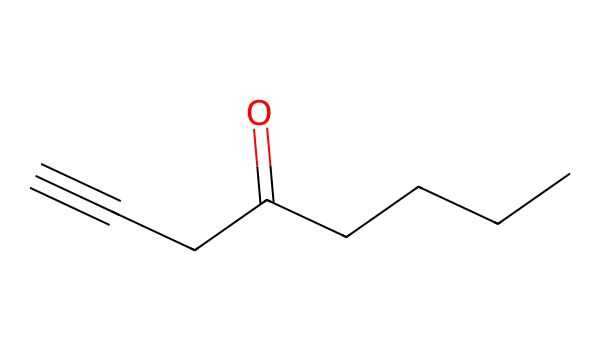

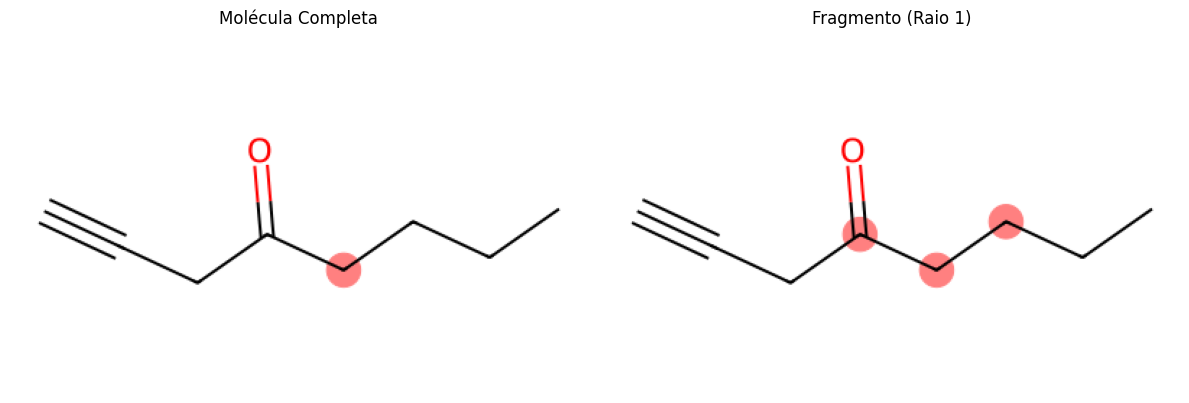

  - Subestrutura isolada:


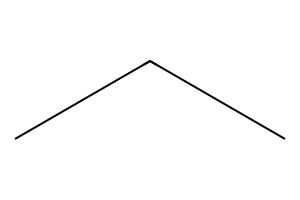

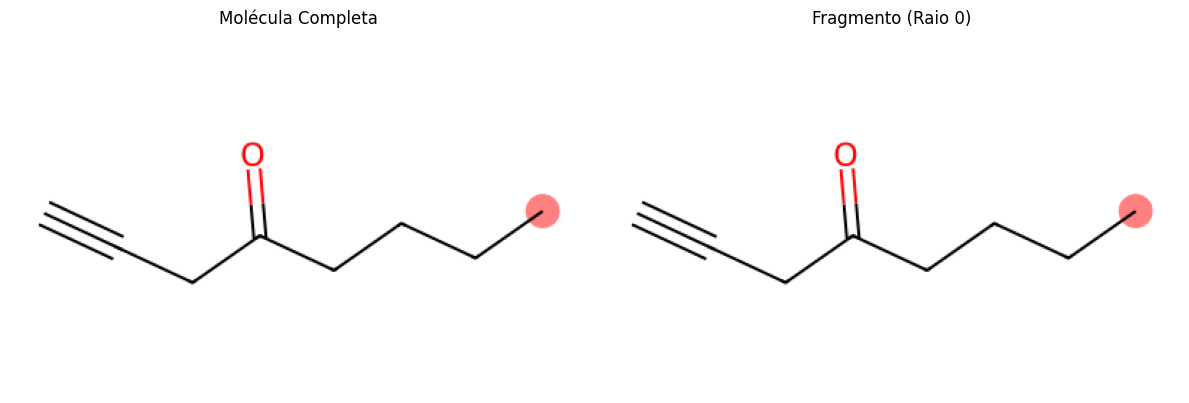

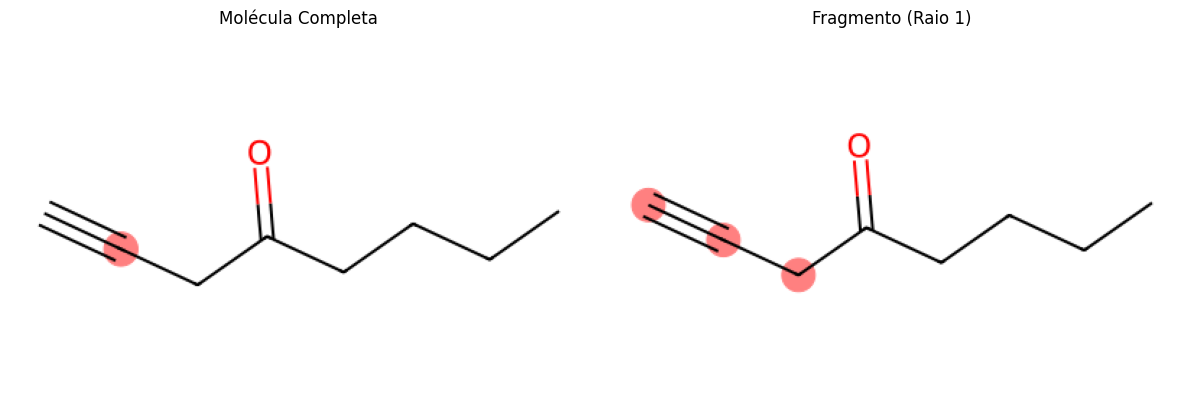

  - Subestrutura isolada:


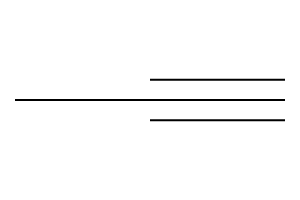

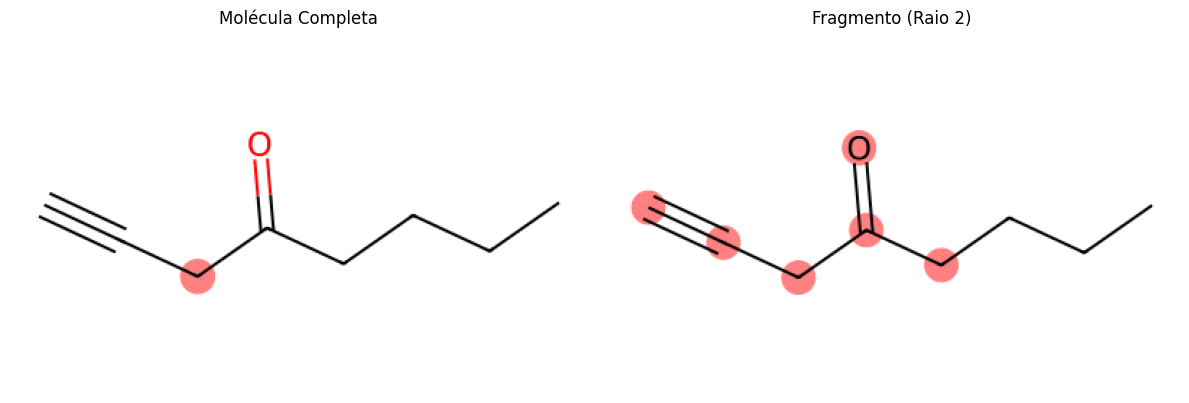

  - Subestrutura isolada:


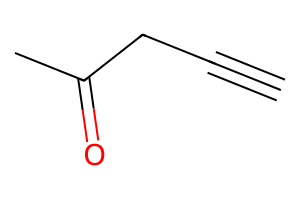

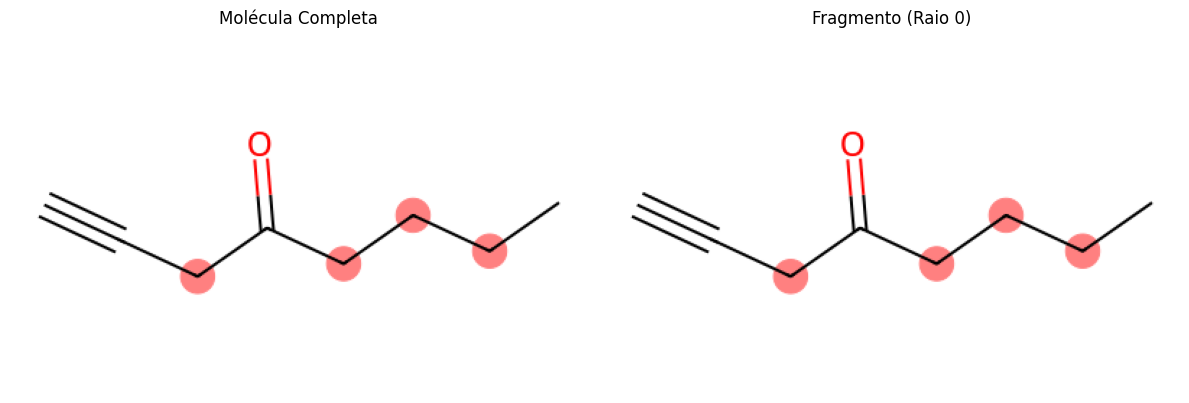

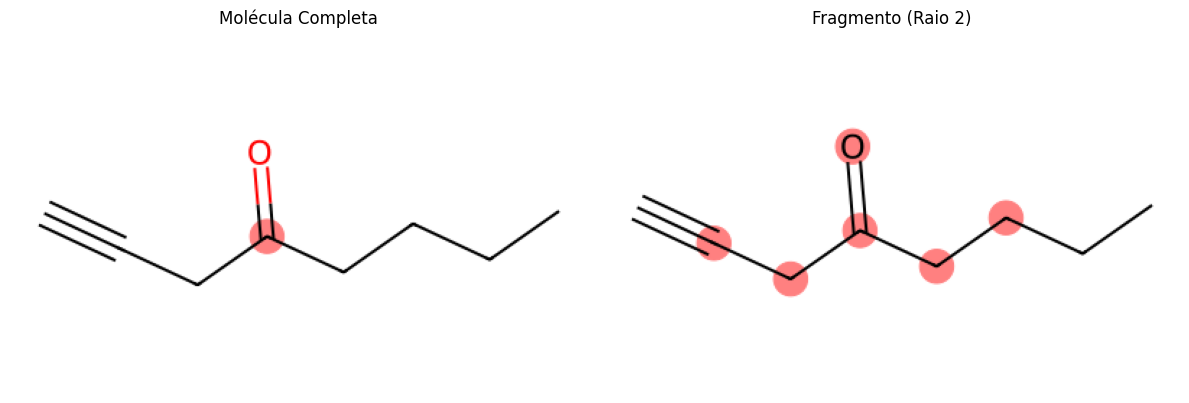

  - Subestrutura isolada:


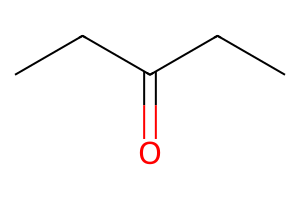

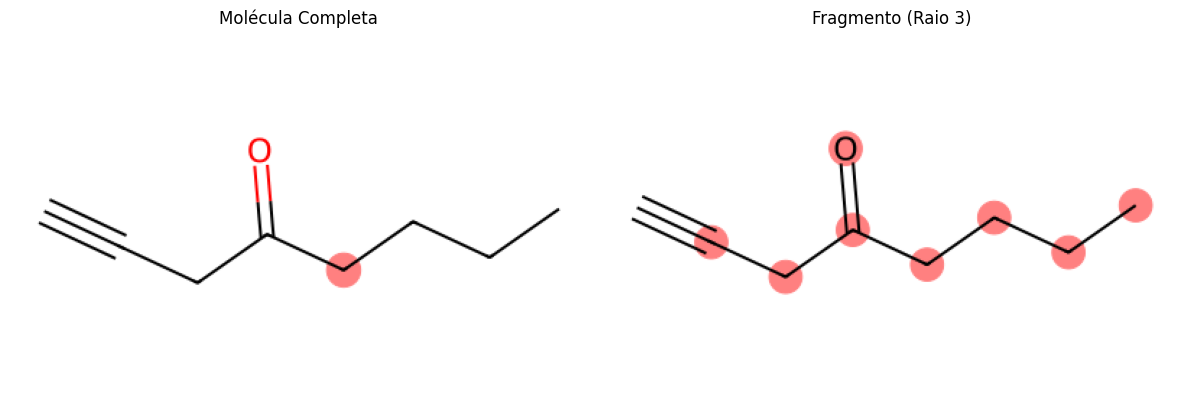

  - Subestrutura isolada:


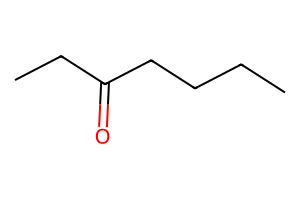

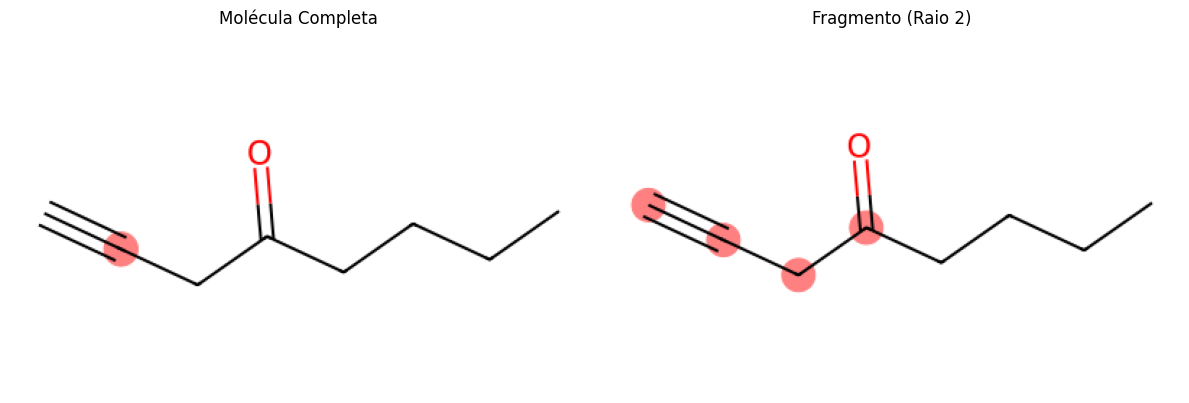

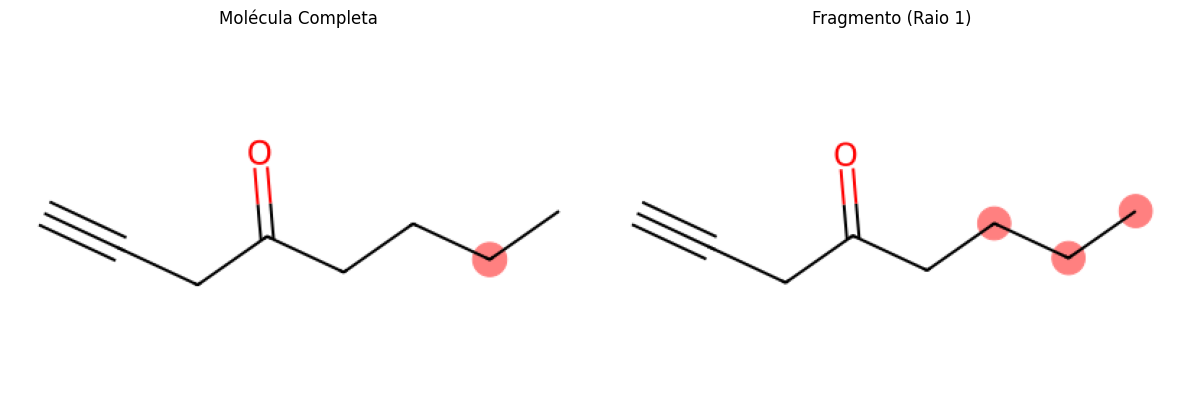

  - Subestrutura isolada:


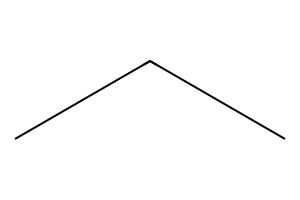

Molécula: CCCCC(=O)CC#C
Total de bits importantes: 225
Total de bits ativos no fingerprint: 23
Os bits destacados em VERMELHO estão ATIVOS (presentes) na molécula.
Os bits destacados em AZUL estão INATIVOS (ausentes) na molécula.

Resumo dos 10 bits mais importantes:
1. 🔵 Bit 0: 0.2882 (INATIVO)
2. 🔵 Bit 1: 0.2743 (INATIVO)
3. 🔵 Bit 2: 0.2721 (INATIVO)
4. 🔵 Bit 3: 0.2413 (INATIVO)
5. 🔵 Bit 4: 0.2405 (INATIVO)
6. 🔵 Bit 6: 0.2100 (INATIVO)
7. 🔵 Bit 7: 0.1992 (INATIVO)
8. 🔵 Bit 8: 0.1828 (INATIVO)
9. 🔵 Bit 10: 0.1691 (INATIVO)
10. 🔵 Bit 11: 0.1691 (INATIVO)
Encontrados 9 fragmentos ativos importantes:
  - Átomo(s) central(is): [3]
  - Ambiente químico: 3 átomos no raio 1

--------------------------------------------------

  - Átomo(s) central(is): [0]
  - Ambiente químico: 1 átomos no raio 0

--------------------------------------------------

  - Átomo(s) central(is): [7]
  - Ambiente químico: 3 átomos no raio 1

--------------------------------------------------

  - Átomo(s) central(i

In [4]:
from chemxai.evaluate import FingerprintAnalyzer
from chemxai.explainers import LIME

# Exemplo de uso da classe
# Calculando explicação LIME para um batch específico
batch_idx = 0
mol_idx = 0

# Obtendo dados do batch
batch_data = next(iter(test_loader))[batch_idx]
background = next(iter(train_loader))[batch_idx]

# Calculando explicação SHAP
explainer = LIME(model=model_without_noise, background_tensor=background, 
                test_tensor=batch_data, device=device)
explanation = explainer.explain_local(index=mol_idx)

# Criando o analisador com a nova assinatura
analyzer = FingerprintAnalyzer(
    explanation=explanation,
    batch_idx=batch_idx,
    mol_idx=mol_idx,
    dataset_type='test',
    device=device
)

# Executar a análise e obter o texto resumo
resultado = analyzer.analyze()
print(resultado)

Background shape: (32, 512)


  0%|          | 0/32 [00:00<?, ?it/s]

Test data shape: (32, 512)


100%|██████████| 32/32 [00:04<00:00,  7.24it/s]


Dados salvos em: /mnt/data/home/jdurao/Documentos/ToolBox-ChemXAI/Testing/data/QM9_tabular_Data
## Molécula Original


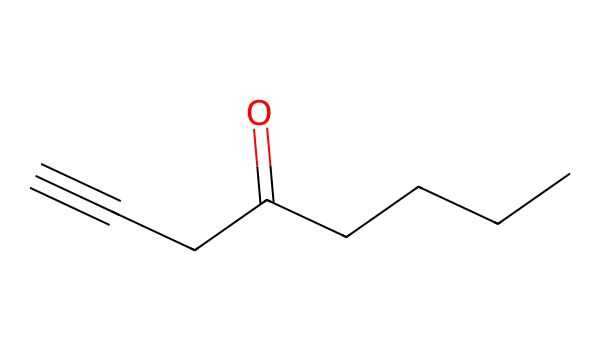

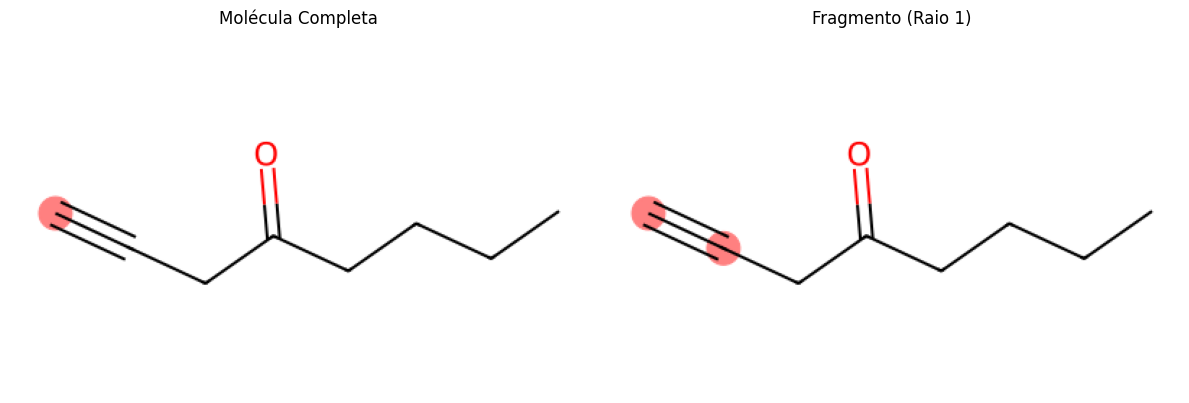

  - Subestrutura isolada:


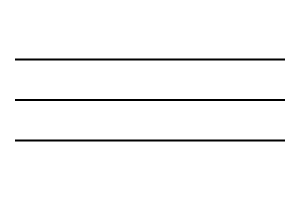

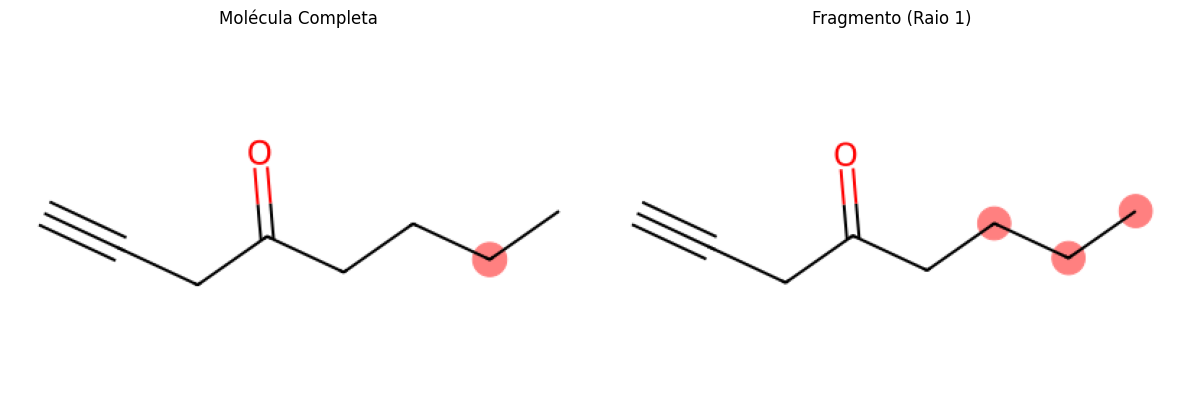

  - Subestrutura isolada:


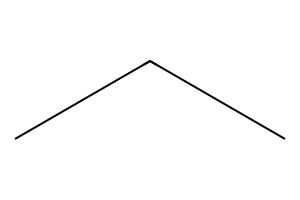

Molécula: CCCCC(=O)CC#C
Total de bits importantes: 10
Total de bits ativos no fingerprint: 23
Os bits destacados em VERMELHO estão ATIVOS (presentes) na molécula.
Os bits destacados em AZUL estão INATIVOS (ausentes) na molécula.

Resumo dos 10 bits mais importantes:
1. 🔵 Bit 144: 0.1468 (INATIVO)
2. 🔴 Bit 462: 0.1233 (ATIVO)
3. 🔵 Bit 356: 0.0921 (INATIVO)
4. 🔵 Bit 492: 0.0884 (INATIVO)
5. 🔵 Bit 314: 0.0838 (INATIVO)
6. 🔵 Bit 182: 0.0824 (INATIVO)
7. 🔵 Bit 285: 0.0696 (INATIVO)
8. 🔵 Bit 94: 0.0609 (INATIVO)
9. 🔴 Bit 282: 0.0606 (ATIVO)
10. 🔵 Bit 36: 0.0421 (INATIVO)
Encontrados 2 fragmentos ativos importantes:
  - Átomo(s) central(is): [8]
  - Ambiente químico: 2 átomos no raio 1

--------------------------------------------------

  - Átomo(s) central(is): [1]
  - Ambiente químico: 3 átomos no raio 1

--------------------------------------------------




In [5]:
from chemxai.evaluate import FingerprintAnalyzer
from chemxai.explainers import Shap

# Exemplo de uso da classe
# Calculando explicação Shap para um batch específico
batch_idx = 0
mol_idx = 0

# Obtendo dados do batch
batch_data = next(iter(test_loader))[batch_idx]
background = next(iter(train_loader))[batch_idx]

# Calculando explicação SHAP
explainer = Shap(model=model_without_noise, background_tensor=background, 
                test_tensor=batch_data, device=device)
explanation = explainer.explain_local(index=mol_idx)

# Criando o analisador com a nova assinatura
analyzer = FingerprintAnalyzer(
    explanation=explanation,
    batch_idx=batch_idx,
    mol_idx=mol_idx,
    dataset_type='test',
    device=device
)

# Executar a análise e obter o texto resumo
resultado = analyzer.analyze()
print(resultado)

In [1]:
from chemxai.data import qm9_tabular

In [2]:
qm9 = qm9_tabular()

train_loader, val_loader, test_loader, train_loader_noise, val_loader_noise, test_loader_noise, is_noise = qm9.get_paired_dataloaders(descriptor_type='Physicochemical')
print(train_loader.dataset[0])
print(train_loader_noise.dataset[0])

Dados já existem em: /mnt/data/home/jdurao/Documentos/ToolBox-ChemXAI/Testing/data/QM9_tabular_Data
(tensor([ 0.4481,  0.5177, -0.5114, -0.9879, -0.2200, -0.8463, -0.4546, -0.2814,
        -0.2198]), tensor([-0.2878]))
(tensor([ 0.4481,  0.5177, -0.5114, -0.9879, -0.2200, -0.8463, -0.4546, -0.2814,
        -0.2198, -1.1878]), tensor([-0.2878]))
